In [1]:
import pandas as pd
import os
import sys
from sklearn.preprocessing import LabelEncoder


In [2]:
cwd= os.getcwd()
print(cwd)
BASE_DIR= os.path.join(cwd,"..")

data= os.path.join(BASE_DIR, "data", "diagnosed_cbc_data_v4.csv")

if cwd != BASE_DIR:
    sys.path.insert(0, BASE_DIR)

from src.feature_selection import FeatureSelection

/home/hngoc/thesis/microcytic-reduced/notebooks


In [3]:
df= pd.read_csv(data)

In [4]:
y= df["Diagnosis"]

le= LabelEncoder()
y_encoded = le.fit_transform(y)

df["Diagnosis"] = y_encoded
# In mapping
for i, label in enumerate(le.classes_):
    print(f"{label} -> {i}")

Healthy -> 0
Iron deficiency anemia -> 1
Leukemia -> 2
Leukemia with thrombocytopenia -> 3
Macrocytic anemia -> 4
Normocytic hypochromic anemia -> 5
Normocytic normochromic anemia -> 6
Other microcytic anemia -> 7
Thrombocytopenia -> 8


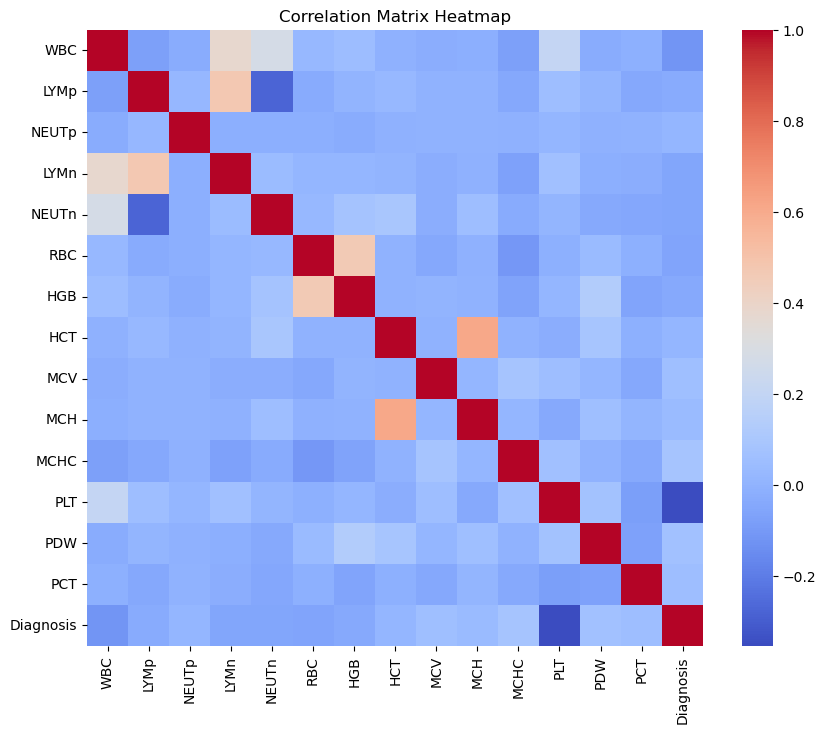

In [5]:
X= df[df.columns[:-1]]
y_encoded= pd.Series(y_encoded, name="Diagnosis")
fs = FeatureSelection(X, y_encoded)
corr_filter= fs.correlation_filter()

In [6]:
rf= fs.get_features_rf()
print(rf)

   feature        rf
0      HGB  0.185146
1      MCV  0.152995
2      MCH  0.152705
3     MCHC  0.146610
4      RBC  0.102059
5      PLT  0.082454
6      WBC  0.052022
7      HCT  0.045467
8      PCT  0.034215
9    NEUTp  0.014794
10   NEUTn  0.012404
11    LYMn  0.008955
12     PDW  0.005610
13    LYMp  0.004563


In [7]:
lr= fs.get_features_lr()
print(lr)

   feature        lr
0      MCV  0.574778
1      PLT  0.342834
2     MCHC  0.335211
3      HGB  0.301155
4      WBC  0.186751
5      RBC  0.159346
6      PCT  0.076448
7    NEUTn  0.049690
8      PDW  0.043512
9     LYMn  0.014823
10    LYMp  0.008192
11   NEUTp  0.006103
12     HCT  0.004305
13     MCH  0.002831


/home/hngoc/miniconda3/envs/ds/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


In [8]:
cb= fs.combine_features()
print(cb)

/home/hngoc/miniconda3/envs/ds/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


   feature        lr        rf     score
0      MCV  1.000000  0.826349  1.826349
1      HGB  0.523950  1.000000  1.523950
2     MCHC  0.583202  0.791863  1.375065
3      PLT  0.596463  0.445344  1.041807
4      MCH  0.004925  0.824784  0.829709
5      RBC  0.277231  0.551233  0.828465
6      WBC  0.324910  0.280978  0.605888
7      PCT  0.133004  0.184799  0.317803
8      HCT  0.007490  0.245575  0.253065
9    NEUTn  0.086451  0.066997  0.153448
10     PDW  0.075702  0.030302  0.106003
11   NEUTp  0.010618  0.079905  0.090524
12    LYMn  0.025789  0.048368  0.074158
13    LYMp  0.014253  0.024644  0.038897


In [9]:
e= fs.evaluate_k(cb)
print(e)

(     k     score       std
0   11  0.951337  0.029290
1   10  0.950911  0.030166
2   12  0.945274  0.030783
3   13  0.943759  0.033782
4    9  0.935704  0.042026
5   15  0.934501  0.041189
6   14  0.934501  0.041189
7   16  0.934501  0.041189
8   17  0.934501  0.041189
9   18  0.934501  0.041189
10  19  0.934501  0.041189
11   8  0.934265  0.021651
12   7  0.931545  0.040516
13   6  0.789991  0.027041
14   5  0.785309  0.021469, 11)


#### Full df after preprocessing

In [10]:
full_df= df.copy()
full_df.to_csv(os.path.join(BASE_DIR, "data", "processed.csv"), index=False)

In [11]:
print(full_df.head())

    WBC  LYMp  NEUTp  LYMn  NEUTn   RBC  HGB    HCT   MCV   MCH  MCHC    PLT  \
0  10.0  43.2   50.1   4.3    5.0  2.77  7.3   24.2  87.7  26.3  30.1  189.0   
1  10.0  42.4   52.3   4.2    5.3  2.84  7.3   25.0  88.2  25.7  20.2  180.0   
2   7.2  30.7   60.7   2.2    4.4  3.97  9.0   30.5  77.0  22.6  29.5  148.0   
3   6.0  30.2   63.5   1.8    3.8  4.22  3.8   32.8  77.9  23.2  29.8  143.0   
4   4.2  39.1   53.7   1.6    2.3  3.93  0.4  316.0  80.6  23.9  29.7  236.0   

    PDW   PCT  Diagnosis  
0  12.5  0.17          5  
1  12.5  0.16          5  
2  14.3  0.14          1  
3  11.3  0.12          1  
4  12.8  0.22          5  


#### Final df

In [12]:
final_df = df.drop(columns=["NEUTp", "LYMn", "LYMp"])
print(final_df.head())

    WBC  NEUTn   RBC  HGB    HCT   MCV   MCH  MCHC    PLT   PDW   PCT  \
0  10.0    5.0  2.77  7.3   24.2  87.7  26.3  30.1  189.0  12.5  0.17   
1  10.0    5.3  2.84  7.3   25.0  88.2  25.7  20.2  180.0  12.5  0.16   
2   7.2    4.4  3.97  9.0   30.5  77.0  22.6  29.5  148.0  14.3  0.14   
3   6.0    3.8  4.22  3.8   32.8  77.9  23.2  29.8  143.0  11.3  0.12   
4   4.2    2.3  3.93  0.4  316.0  80.6  23.9  29.7  236.0  12.8  0.22   

   Diagnosis  
0          5  
1          5  
2          1  
3          1  
4          5  


In [13]:
final_df.to_csv(os.path.join(BASE_DIR, "data", "final.csv"), index=False)